# Ames House Price Prediction — Data Understanding

**Problem:** Predict residential sale prices from property characteristics.  
**Target:** `SalePrice`  
**Task:** Supervised regression

This notebook focuses on understanding the dataset before preprocessing and modeling.

Main goals:
- inspect the dataset structure and feature types,
- understand the target distribution,
- investigate potential target outliers,
- distinguish structural missingness from genuinely missing information,
- examine missingness patterns that may affect later preprocessing decisions.

## 1. Load the dataset

The Ames Housing dataset is loaded from OpenML as a pandas DataFrame.

- `X` contains the predictor variables.
- `y` contains the target variable, `SalePrice`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

housing = fetch_openml(
    data_id=42165,
    as_frame=True
)

X = housing.data
y = housing.target

## 2. Dataset structure

Before analyzing individual features, we inspect:
- the first observations,
- the number of rows and columns,
- and the pandas data types.

This gives an initial picture of the structure that later preprocessing steps must handle.

In [2]:
X.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


In [3]:
X.shape, y.shape

((1460, 80), (1460,))

The dataset contains **1,460 houses and 80 predictor columns**.

- `X`: `(1460, 80)`
- `y`: `(1460,)`

Each row represents one house, while each column represents one property characteristic.

In [4]:
X.dtypes

Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MiscVal            int64
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
Length: 80, dtype: object

### Data type vs. statistical meaning

A pandas data type does not necessarily represent the statistical meaning of a feature.

For example, a feature may be stored as an integer while actually representing categories or ordered levels. Feature treatment should therefore be based on semantic meaning, not only on pandas dtype.

In [5]:
num_features = len(X.select_dtypes(include="number").columns)
non_num_features = len(X.select_dtypes(exclude="number").columns)

num_features, non_num_features

(37, 43)

Based only on pandas dtypes:
- **37 features** are stored as numerical values.
- **43 features** are stored as non-numerical values.

This is a technical classification only. Some numerically stored features may still need categorical or ordinal treatment later.

## 3. Target analysis

Before building a regression model, we need to understand the target distribution.

Questions of interest:
- What is the typical sale price?
- How dispersed are prices?
- Is the distribution symmetric?
- Are there unusually expensive or inexpensive houses?

In [6]:
y.describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

The mean sale price is higher than the median, which already suggests a longer upper tail in the target distribution.

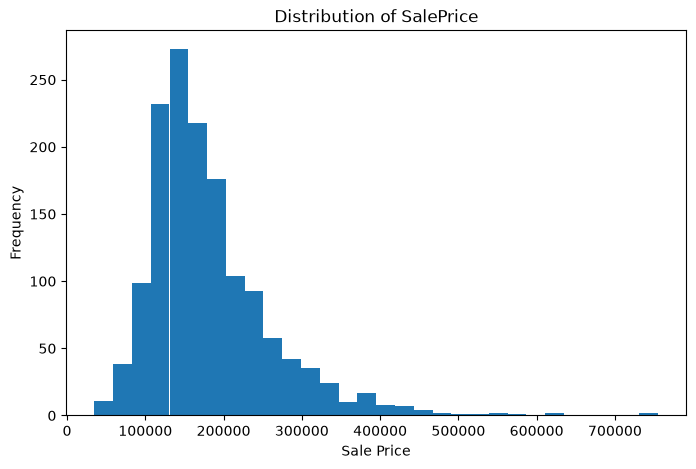

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(y, bins=30)
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.title("Distribution of SalePrice")
plt.show()

The histogram shows a clear **right-skewed distribution**.

Most houses are concentrated in the lower and middle price ranges, while a smaller number of expensive properties form a long right tail.

In [8]:
y.skew()

np.float64(1.8828757597682129)

The positive skewness value confirms the right-skewed pattern observed in the histogram.

### Candidate outliers using the IQR rule

The interquartile range is used as an initial diagnostic tool for extreme target values.

The rule defines:
- lower fence = Q1 − 1.5 × IQR
- upper fence = Q3 + 1.5 × IQR

Values outside these limits are treated as **candidate outliers**, not automatically as invalid observations.

In [9]:
q_1 = y.quantile(0.25)
q_3 = y.quantile(0.75)

iqr = q_3 - q_1

lower_fence = q_1 - 1.5 * iqr
upper_fence = q_3 + 1.5 * iqr

print(
    f"Q1 = {q_1}, "
    f"Q3 = {q_3}, "
    f"lower fence = {lower_fence}, "
    f"upper fence = {upper_fence}"
)

Q1 = 129975.0, Q3 = 214000.0, lower fence = 3937.5, upper fence = 340037.5


In [10]:
outlier_candidate_count = y > upper_fence
outlier_candidate_count.sum()

np.int64(61)

In [11]:
(y < lower_fence).sum()

np.int64(0)

The IQR rule identifies:
- **61 observations above the upper fence**
- **0 observations below the lower fence**

Because the target is strongly right-skewed, legitimate high-value properties may be flagged as outliers. These observations should therefore be investigated before any removal decision.

In [12]:
y[y > upper_fence]

11      345000
53      385000
58      438780
112     383970
151     372402
         ...  
1268    381000
1353    410000
1373    466500
1388    377500
1437    394617
Name: SalePrice, Length: 61, dtype: int64

To determine whether high-price observations are data errors or legitimate properties, several economically meaningful features are inspected:
- `OverallQual`: overall property quality
- `GrLivArea`: above-ground living area
- `Neighborhood`: location
- `GarageCars`: garage capacity

In [13]:
X.loc[
    y > upper_fence,
    ["OverallQual", "GrLivArea", "Neighborhood", "GarageCars"]
]

,OverallQual,GrLivArea,Neighborhood,GarageCars
11,9,2324,NridgHt,3
53,9,1842,Veenker,3
58,10,2945,StoneBr,3
112,7,2696,CollgCr,3
151,8,1710,NridgHt,3
...,...,...,...,...
1268,8,3447,Crawfor,3
1353,8,3238,NoRidge,3
1373,10,2633,NoRidge,3
1388,9,1746,Gilbert,3


The expensive observations generally correspond to houses with characteristics consistent with high-value properties.

**Conclusion:** the upper-tail observations appear to represent a legitimate high-price market segment rather than obvious data errors, so they are retained.

## 4. Missing values analysis

Missing values are not always equivalent to missing information.

A missing value may mean:
1. the feature does not exist for that house (**structural missingness**), or
2. the feature exists but its value was not recorded (**true missingness**).

The goals of this section are to determine:
- which features contain missing values,
- how frequent the missing values are,
- whether missingness follows meaningful structural patterns,
- and which cases require further investigation.

In [14]:
missing_count = X.isna().sum()
missing_percentage = (missing_count / len(X)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percentage": missing_percentage
})

The initial table includes all features. We keep only features with at least one missing value and sort them from highest to lowest missing percentage.

In [15]:
mask = missing_summary["missing_count"] > 0

missing_summary = (
    missing_summary[mask]
    .sort_values(by="missing_percentage", ascending=False)
)

missing_summary

,missing_count,missing_percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945
GarageQual,81,5.547945


A high missing percentage does not automatically justify dropping a feature.

For example, missing values in pool, garage, fireplace, or basement features may indicate that the corresponding structure does not exist. Missingness therefore needs to be interpreted using related features.

### 4.1 Garage features

Several garage-related features contain exactly 81 missing values.

Equal counts alone do not prove that the same houses are missing in every column, so their boolean missing masks are compared row by row.

In [16]:
garage_type_missing = X["GarageType"].isna()
garage_year_missing = X["GarageYrBlt"].isna()

(garage_type_missing == garage_year_missing).all()

np.True_

In [17]:
garage_finish_missing = X["GarageFinish"].isna()

(garage_type_missing == garage_finish_missing).all()

np.True_

In [18]:
garage_quality_missing = X["GarageQual"].isna()

(garage_type_missing == garage_quality_missing).all()

np.True_

In [19]:
garage_condition_missing = X["GarageCond"].isna()

(garage_type_missing == garage_condition_missing).all()

np.True_

All garage-related missing masks match exactly.

`GarageType`, `GarageYrBlt`, `GarageFinish`, `GarageQual`, and `GarageCond` are missing for the same 81 houses.

**Conclusion:** this is strong evidence that these missing values are structural and correspond to houses without a garage.

### 4.2 Basement features

Most basement-related columns contain 37 missing values, while `BsmtExposure` and `BsmtFinType2` contain 38.

This suggests that most basement missingness may be structural, with one additional genuinely missing observation in each of those two columns.

In [20]:
basement_quality_missing = X["BsmtQual"].isna()

In [21]:
basement_condition_missing = X["BsmtCond"].isna()

(basement_quality_missing == basement_condition_missing).all()

np.True_

In [22]:
basement_exposure_missing = X["BsmtExposure"].isna()

(basement_quality_missing == basement_exposure_missing).all()

np.False_

In [23]:
basement_finish_type_1_missing = X["BsmtFinType1"].isna()

(basement_quality_missing == basement_finish_type_1_missing).all()

np.True_

In [24]:
basement_finish_type_2_missing = X["BsmtFinType2"].isna()

(basement_quality_missing == basement_finish_type_2_missing).all()

np.False_

`BsmtQual`, `BsmtCond`, and `BsmtFinType1` share the same missing pattern.

`BsmtExposure` and `BsmtFinType2` do not, so the exact mismatching observations are identified.

In [25]:
basement_exposure_mismatch = (
    basement_quality_missing != basement_exposure_missing
)

basement_exposure_mismatch.sum()

np.int64(1)

In [26]:
basement_finish_type_2_mismatch = (
    basement_quality_missing != basement_finish_type_2_missing
)

basement_finish_type_2_mismatch.sum()

np.int64(1)

Each feature contains exactly **one mismatch** relative to the main structural basement-missing pattern.

The corresponding basement measurements are inspected to determine whether those values are truly missing.

In [27]:
basement_cols = [
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "TotalBsmtSF",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF"
]

In [28]:
X.loc[basement_exposure_mismatch, basement_cols]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,TotalBsmtSF,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF
948,Gd,TA,NaN,Unf,Unf,936,0,0,936


In [29]:
X.loc[basement_finish_type_2_mismatch, basement_cols]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,TotalBsmtSF,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF
332,Gd,TA,No,GLQ,NaN,3206,1124,479,1603


The mismatching houses clearly contain basements:
- basement quality and condition are recorded,
- total basement area is greater than zero,
- and other basement measurements are available.

For the `BsmtFinType2` mismatch, `BsmtFinSF2` is also positive, confirming that a second finished basement area exists.

**Conclusion:**
- the shared 37 missing observations are most likely structural,
- one `BsmtExposure` value is genuinely missing,
- one `BsmtFinType2` value is genuinely missing.

A single feature can therefore contain both structural and true missing values.

### 4.3 Masonry veneer features

`MasVnrType` describes the masonry veneer type, while `MasVnrArea` records its area.

Both columns contain eight missing values. We first check whether those missing values occur in exactly the same rows.

In [30]:
masonry_veneer_type_missing = X["MasVnrType"].isna()
masonry_veneer_area_missing = X["MasVnrArea"].isna()

(
    masonry_veneer_type_missing
    == masonry_veneer_area_missing
).all()

np.True_

The missing patterns are identical: the same eight houses are missing both masonry veneer type and area.

Those rows and related exterior features are inspected next.

In [31]:
X.loc[
    masonry_veneer_type_missing,
    ["MasVnrType", "MasVnrArea", "Exterior1st", "Exterior2nd"]
]

,MasVnrType,MasVnrArea,Exterior1st,Exterior2nd
234,NaN,NaN,VinylSd,VinylSd
529,NaN,NaN,'Wd Sdng',Stone
650,NaN,NaN,CemntBd,CmentBd
936,NaN,NaN,VinylSd,VinylSd
973,NaN,NaN,CemntBd,CmentBd
977,NaN,NaN,VinylSd,VinylSd
1243,NaN,NaN,VinylSd,VinylSd
1278,NaN,NaN,VinylSd,VinylSd


To understand how the dataset represents houses without masonry veneer, the full category counts are inspected.

`dropna=False` keeps missing values visible in the output.

In [32]:
X["MasVnrType"].value_counts(dropna=False)

MasVnrType
None       864
BrkFace    445
Stone      128
BrkCmn      15
NaN          8
Name: count, dtype: int64

The category `"None"` exists explicitly, suggesting that the absence of masonry veneer is represented separately from missing information.

We verify this by examining observations where veneer area equals zero.

In [33]:
X.loc[
    X["MasVnrArea"] == 0,
    ["MasVnrType", "MasVnrArea"]
]

,MasVnrType,MasVnrArea
1,None,0.0
3,None,0.0
5,None,0.0
8,None,0.0
9,None,0.0
...,...,...
1454,None,0.0
1455,None,0.0
1457,None,0.0
1458,None,0.0


The dominant pattern is:

`MasVnrType = "None"` and `MasVnrArea = 0`

Therefore, the eight rows where both values are actually missing are more consistent with **true missing information** than with structural absence.

The pair is not perfectly consistent, so possible data-quality anomalies are also checked.

In [34]:
X.loc[
    (X["MasVnrType"] == "None") & (X["MasVnrArea"] > 0),
    ["MasVnrType", "MasVnrArea"]
]

,MasVnrType,MasVnrArea
624,None,288.0
773,None,1.0
1230,None,1.0
1300,None,344.0
1334,None,312.0


In [35]:
X.loc[
    (X["MasVnrType"] != "None")
    & X["MasVnrType"].notna()
    & (X["MasVnrArea"] == 0),
    ["MasVnrType", "MasVnrArea"]
]

,MasVnrType,MasVnrArea
688,BrkFace,0.0
1241,Stone,0.0


Masonry veneer findings:
- 8 rows are missing both `MasVnrType` and `MasVnrArea`,
- these rows are likely true missing values,
- 5 rows contain `"None"` while reporting a positive veneer area,
- and one additional observation has a masonry veneer type but area `0`.

These inconsistencies are retained for now and recorded as data-quality observations rather than automatically corrected or removed.

### 4.4 Electrical system

`Electrical` contains only one missing value.

Because an electrical system is expected for a residential property, the missing observation is inspected alongside other building-system variables.

In [36]:
electrical_cols = [
    "Electrical",
    "YearBuilt",
    "YearRemodAdd",
    "OverallQual",
    "OverallCond",
    "CentralAir",
    "Heating",
    "HeatingQC"
]

electrical_missing = X["Electrical"].isna()

electrical_missing.sum()

np.int64(1)

In [37]:
X.loc[electrical_missing, electrical_cols]

,Electrical,YearBuilt,YearRemodAdd,OverallQual,OverallCond,CentralAir,Heating,HeatingQC
1379,NaN,2006,2007,5,5,Y,GasA,Gd


The house has normal recorded values for construction year, heating, central air, and overall condition, while only `Electrical` is absent.

**Conclusion:** the single missing `Electrical` value is a true missing value, not a structural absence.

### 4.5 Lot frontage

`LotFrontage` represents the length of the property boundary connected to a street.

Its missing values are investigated as likely true missing values. We also test whether missingness is associated with observable property characteristics such as lot configuration and neighborhood.

In [38]:
lot_frontage_cols = [
    "LotFrontage",
    "LotArea",
    "LotShape",
    "LotConfig",
    "Neighborhood",
    "Street"
]

lot_frontage_missing = X["LotFrontage"].isna()

lot_frontage_missing.sum()

np.int64(259)

In [39]:
X.loc[lot_frontage_missing, lot_frontage_cols]

,LotFrontage,LotArea,LotShape,LotConfig,Neighborhood,Street
7,NaN,10382,IR1,Corner,NWAmes,Pave
12,NaN,12968,IR2,Inside,Sawyer,Pave
14,NaN,10920,IR1,Corner,NAmes,Pave
16,NaN,11241,IR1,CulDSac,NAmes,Pave
24,NaN,8246,IR1,Inside,Sawyer,Pave
...,...,...,...,...,...,...
1429,NaN,12546,IR1,Corner,NWAmes,Pave
1431,NaN,4928,IR1,Inside,NPkVill,Pave
1441,NaN,4426,Reg,Inside,CollgCr,Pave
1443,NaN,8854,Reg,Inside,BrkSide,Pave


`LotFrontage` contains **259 missing observations**, approximately **17.7%** of the dataset.

Because 259 rows are too many for reliable manual inspection, missing rates are compared across meaningful groups.

#### Missing rate by lot configuration

The missing mask contains:
- `True` when `LotFrontage` is missing,
- `False` when it is observed.

In numerical operations, `True` behaves like 1 and `False` like 0. Therefore, the mean of the boolean mask within a group equals the proportion of missing values in that group.

In [40]:
lot_config_missing_stats = (
    lot_frontage_missing
    .groupby(X["LotConfig"])
    .agg(["mean", "size"])
)

lot_config_missing_stats["mean"] *= 100

lot_config_missing_stats

,mean,size
LotConfig,,
Corner,23.574144,263
CulDSac,52.127660,94
FR2,29.787234,47
FR3,0.000000,4
Inside,12.737643,1052


The missing rate varies substantially across lot configurations.

Notable observations:
- `CulDSac` has a missing rate of about 52% across 94 observations.
- `Inside` has a missing rate of about 13% across more than 1,000 observations.
- `FR3` shows 0% missingness, but the group contains only four observations, so that rate is not reliable.

**Interpretation:** `LotFrontage` missingness is associated with `LotConfig`; it does not appear completely random with respect to this observed feature.

#### Missing rate by neighborhood

The same analysis is repeated across neighborhoods to determine whether geographic location is also associated with missingness.

In [41]:
neighborhood_missing_stats = (
    lot_frontage_missing
    .groupby(X["Neighborhood"])
    .agg(["mean", "size"])
)

neighborhood_missing_stats["mean"] *= 100

neighborhood_missing_stats

,mean,size
Neighborhood,,
Blmngtn,17.647059,17
Blueste,0.000000,2
BrDale,0.000000,16
BrkSide,12.068966,58
ClearCr,53.571429,28
CollgCr,16.000000,150
Crawfor,19.607843,51
Edwards,8.000000,100
Gilbert,37.974684,79


Missing rates also vary considerably between neighborhoods.

Some neighborhoods have missing rates above 30%, while others are close to zero despite having comparable sample sizes.

**Interpretation:** `LotFrontage` missingness is also associated with `Neighborhood`.

This is an association, not evidence that neighborhood causes missingness.

#### Does frontage itself differ across neighborhoods?

Different missing rates do not automatically justify neighborhood-based imputation.

To evaluate whether neighborhood-specific imputation could be useful, we also examine whether the actual `LotFrontage` values differ across neighborhoods.

In [42]:
frontage_stats = (
    X.groupby("Neighborhood")["LotFrontage"]
    .agg(["median", "count"])
)

frontage_stats

,median,count
Neighborhood,,
Blmngtn,43.0,14
Blueste,24.0,2
BrDale,21.0,16
BrkSide,52.0,51
ClearCr,80.0,13
CollgCr,70.0,126
Crawfor,74.0,41
Edwards,65.5,92
Gilbert,65.0,49


Neighborhood medians differ substantially, suggesting that a single dataset-wide median may ignore meaningful geographic structure.

However, a neighborhood median is more trustworthy when it is based on enough observed values. The `count` column shows how many non-missing frontage values contribute to each median.

In [43]:
missing_stats = (
    lot_frontage_missing
    .groupby(X["Neighborhood"])
    .agg(["mean", "size"])
)

Both summary tables use `Neighborhood` as their index, so they can be joined directly into one diagnostic table.

In [44]:
neighborhood_frontage_summary = (
    frontage_stats
    .join(missing_stats)
    .rename(columns={
        "median": "median_frontage",
        "count": "non_missing_count",
        "mean": "missing_rate_pct",
        "size": "total_count"
    })
)

neighborhood_frontage_summary["missing_rate_pct"] *= 100

neighborhood_frontage_summary

,median_frontage,non_missing_count,missing_rate_pct,total_count
Neighborhood,,,,
Blmngtn,43.0,14,17.647059,17
Blueste,24.0,2,0.000000,2
BrDale,21.0,16,0.000000,16
BrkSide,52.0,51,12.068966,58
ClearCr,80.0,13,53.571429,28
CollgCr,70.0,126,16.000000,150
Crawfor,74.0,41,19.607843,51
Edwards,65.5,92,8.000000,100
Gilbert,65.0,49,37.974684,79


#### Lot frontage findings

`LotFrontage` contains true missing values.

Its missingness is associated with both `Neighborhood` and `LotConfig`, and median frontage differs substantially across neighborhoods.

Neighborhood-aware imputation is therefore a reasonable candidate strategy. However, some neighborhoods contain very few observed frontage values, making their medians unstable.

Candidate strategies for later validation:
- global median imputation,
- neighborhood median imputation,
- neighborhood median imputation with a fallback for small groups.

No imputation is applied at this stage.

## 5. Train / final holdout split

Up to this point, the full dataset has been used only for descriptive data understanding.

Before learning preprocessing parameters, engineering features, selecting models, or tuning hyperparameters, a final holdout set is separated.

The split is:
- **80% training/development data**
- **20% final holdout data**

`random_state=42` keeps the split reproducible.

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1168, 80), (292, 80), (1168,), (292,))

The split produces:
- `X_train`: 1,168 houses × 80 features
- `X_test`: 292 houses × 80 features
- `y_train`: 1,168 target values
- `y_test`: 292 target values

From this point forward, preprocessing statistics and modeling decisions must be learned from the training/development data only.

The final holdout set should remain untouched until the final evaluation stage to avoid data leakage.